# Capítulo 4 — Soluções dos exercícios complementares

**Curso de Meteorologia Prática** — baseado em R. Stull, *Practical Meteorology* (CC BY-NC-SA 4.0).

> **Para o professor.** Soluções dos teóricos **T1–T5** e numéricos **N1–N4** do Cap. 4. Não distribuir antes da entrega.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from scipy.integrate import solve_ivp
from scipy.optimize import brentq
import sys; sys.path.append('../comum')
from estilo_meteo import aplicar_estilo, CORES
aplicar_estilo()

e0, T0, Rv, Lv, eps = 0.6113, 273.15, 461.0, 2.5e6, 0.622
Cp, Rd, g = 1004.0, 287.0, 9.8

## T1 — Integração de Clausius–Clapeyron

**Solução.** Separando variáveis em $de_s/e_s = (L_v/\Re_v)\,dT/T^2$ e integrando de $(T_0,e_0)$ a $(T,e_s)$:
$$\ln\frac{e_s}{e_0} = \frac{L_v}{\Re_v}\left(\frac{1}{T_0}-\frac{1}{T}\right)\;\Rightarrow\;\text{fórmula do livro. ∎}$$
Com $L_v$ variável ($-2370$ J/kg por K), o expoente ganha um termo logarítmico; o erro da fórmula constante fica abaixo de ~2 % entre −40 e +40 °C (verificação numérica no N1).

In [2]:
# verificação simbólica
T_, T0_, e0_, L_, Rv_ = sp.symbols('T T_0 e_0 L R_v', positive=True)
es_ = sp.Function('e_s', positive=True)
solucao = sp.dsolve(sp.Eq(es_(T_).diff(T_), L_*es_(T_)/(Rv_*T_**2)), es_(T_),
                    ics={es_(T0_): e0_})
display(sp.simplify(solucao))
print('→ exatamente a forma do livro ✓')

Eq(e_s(T), e_0*exp(L*(T - T_0)/(R_v*T*T_0)))

→ exatamente a forma do livro ✓


## T2 — A regra dos 7 %/K

**Solução.** $\dfrac{d\ln e_s}{dT} = \dfrac{L_v}{\Re_v T^2}$. Em $T = 300$ K: $\dfrac{2{,}5\times10^6}{461\times 9\times10^4} = 0{,}060$ K$^{-1}$ ≈ 6 %/K (7 %/K a 288 K). Num clima 2 K mais quente, a mesma circulação convergindo o mesmo ar úmido carrega ~14 % mais vapor — chuvas extremas intensificam nessa taxa (ou mais, com feedback dinâmico).

In [3]:
for TK in [273.15, 288.15, 300.15]:
    taxa = Lv/(Rv*TK**2)*100
    print(f'T = {TK-273.15:5.1f} °C:  d ln es/dT = {taxa:.1f} %/K')

T =   0.0 °C:  d ln es/dT = 7.3 %/K
T =  15.0 °C:  d ln es/dT = 6.5 %/K
T =  27.0 °C:  d ln es/dT = 6.0 %/K


## T3 — Dedução de $r = \varepsilon e/(P-e)$

**Solução.** Gás ideal para cada espécie no mesmo volume e temperatura:
$\rho_v = e/(\Re_v T)$ e $\rho_d = (P-e)/(\Re_d T)$. Logo
$$r = \frac{\rho_v}{\rho_d} = \frac{e}{P-e}\cdot\frac{\Re_d}{\Re_v} = \frac{\varepsilon\,e}{P-e},$$
pois $\Re_d/\Re_v = M_v/M_d = 18{,}02/28{,}97 = 0{,}622$. ∎

## T4 — A regra dos 125 m/°C

**Solução.** Na subida com $r$ constante, $e \propto P$, então $\ln e_s(T_d) = \ln e + $const dá, derivando em $z$:
$$\frac{L_v}{\Re_v T_d^2}\frac{dT_d}{dz} = \frac{1}{P}\frac{dP}{dz} = -\frac{g}{\Re_d T}
\;\Rightarrow\; \frac{dT_d}{dz} = -\frac{g\,\Re_v T_d^2}{L_v \Re_d T}.$$
Com $T \approx T_d \approx 290$ K: $dT_d/dz \approx -1{,}8$ K/km. A parcela fecha o intervalo $(T - T_d)$ à taxa $\Gamma_d - 1{,}8 = 8{,}0$ K/km, logo $z_{LCL} = (T-T_d)/8{,}0$ K/km $= 125$ m/°C. ∎

In [4]:
Td = 290.0; T = 290.0
dTd_dz = -g*Rv*Td**2/(Lv*Rd*T)*1e3
print(f'dTd/dz = {dTd_dz:.2f} K/km;  fechamento = {9.8 + dTd_dz:.1f} K/km;  '
      f'a = {1e3/(9.8 + dTd_dz):.0f} m/°C ✓')

dTd/dz = -1.83 K/km;  fechamento = 8.0 K/km;  a = 125 m/°C ✓


## T5 — Água precipitável analítica

**Solução.** A massa de vapor num elemento de coluna é $dm_v = q\,dm \approx r\,dP/g$ por área (Cap. 1, T4). Convertendo em altura de água líquida ($W = m_v/\rho_{liq}$):
$$W = \frac{1}{\rho_{liq}\,g}\int_0^{P_{sfc}} r\,dP.$$
Para $r = r_0(P/P_0)^3$:
$$W = \frac{r_0}{\rho_{liq}\,g}\int_0^{P_0}\left(\frac{P}{P_0}\right)^3 dP = \frac{r_0 P_0}{4\rho_{liq} g}.$$

In [5]:
r0, P0_kPa = 0.020, 100.0
W = r0*P0_kPa*1e3/(4*1000.0*g)*1e3   # mm
print(f'W = r0·P0/(4·ρ·g) = {W:.1f} mm — típico de atmosfera tropical ✓')

W = r0·P0/(4·ρ·g) = 51.0 mm — típico de atmosfera tropical ✓


---
## N1 — Clausius–Clapeyron com $L_v(T)$ variável

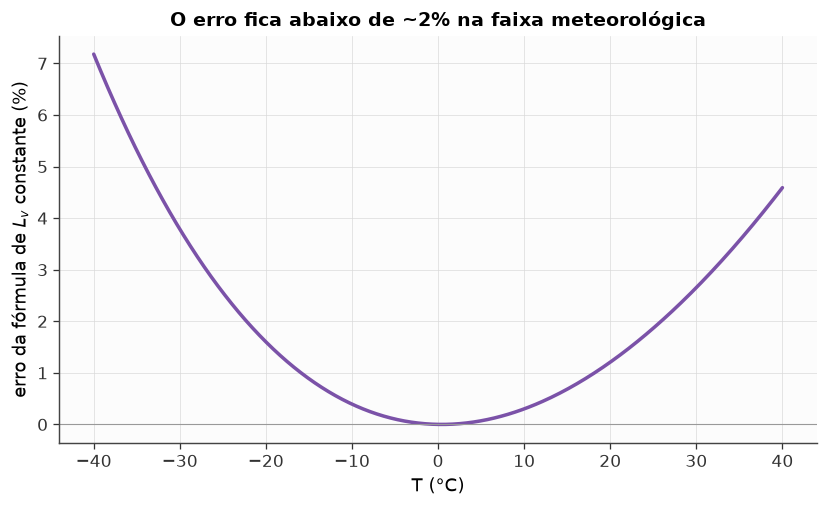

erro máximo na faixa: 7.2 %


In [6]:
Lv_T = lambda TT: 2.501e6 - 2370.0*(TT - 273.15)

T = np.linspace(233.15, 313.15, 400)
quente = solve_ivp(lambda TT, es: Lv_T(TT)*es/(Rv*TT**2), [T0, T[-1]], [e0],
                   dense_output=True, rtol=1e-10)
frio = solve_ivp(lambda TT, es: Lv_T(TT)*es/(Rv*TT**2), [T0, T[0]], [e0],
                 dense_output=True, rtol=1e-10)
es_var = np.where(T >= T0, quente.sol(T)[0], frio.sol(T)[0])
es_cte = e0*np.exp((Lv/Rv)*(1/T0 - 1/T))

fig, ax = plt.subplots(figsize=(8.5, 4.6))
ax.plot(T - 273.15, 100*(es_cte - es_var)/es_var, color=CORES['roxo'])
ax.axhline(0, color='#999999', lw=0.7)
ax.set(xlabel='T (°C)', ylabel='erro da fórmula de $L_v$ constante (%)',
       title='O erro fica abaixo de ~2% na faixa meteorológica')
plt.show()
print(f'erro máximo na faixa: {np.max(np.abs(100*(es_cte-es_var)/es_var)):.1f} %')

## N2 — Psicrômetro digital

In [7]:
from metpy.units import units
import metpy.calc as mpcalc

T_ar, T_w, P = 30.0, 24.0, 93.0    # °C, °C, kPa
es_kPa = lambda T_C: e0*np.exp((Lv/Rv)*(1/T0 - 1/(T_C + 273.15)))
rs = lambda T_C: eps*es_kPa(T_C)/(P - es_kPa(T_C))

gamma = Cp/Lv                                      # K^-1 (em kg/kg por K)
r = rs(T_w) - gamma*(T_ar - T_w)
e = r*P/(eps + r)
UR = 100*e/es_kPa(T_ar)
print(f'psicrométrica manual : r = {1e3*r:.1f} g/kg | UR = {UR:.0f}%')

UR_mp = mpcalc.relative_humidity_wet_psychrometric(
    (P*10)*units.hPa, T_ar*units.degC, T_w*units.degC)
print(f'MetPy                : UR = {100*UR_mp.magnitude:.0f}%  (validação ✓)')

psicrométrica manual : r = 18.6 g/kg | UR = 62%
MetPy                : UR = 62%  (validação ✓)


## N3 — LCL da sondagem e o dia seco

LCL exato: 929 hPa ≈ 638 m | regra: 625 m


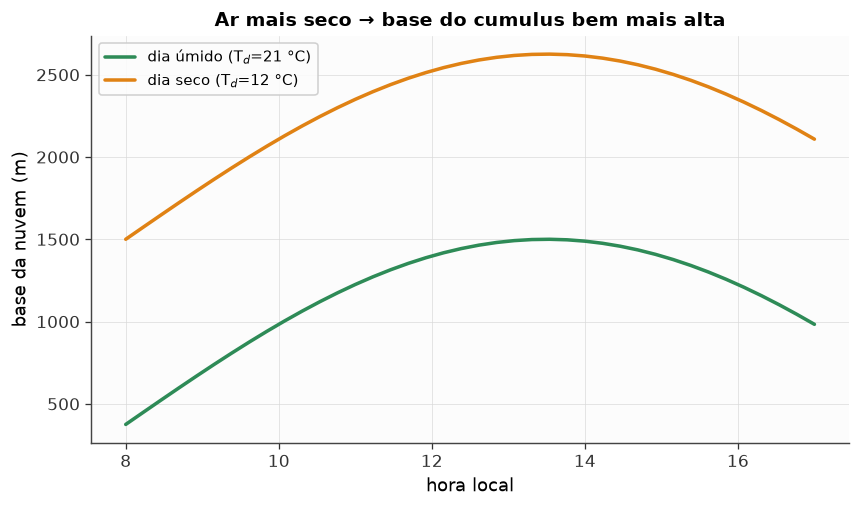

às 14 h: úmido 1489 m | seco 2614 m


In [8]:
# parcela de superfície da sondagem tropical: P=1000 hPa, T=27, Td=22
p_lcl, T_lcl = mpcalc.lcl(1000*units.hPa, 27*units.degC, 22*units.degC)
Tv_m = 0.5*(27 + T_lcl.to('degC').magnitude) + 273.15
z_lcl = Rd/g*Tv_m*np.log(1000/p_lcl.to('hPa').magnitude)
print(f'LCL exato: {p_lcl.to("hPa").magnitude:.0f} hPa ≈ {z_lcl:.0f} m | '
      f'regra: {125*(27-22):.0f} m')

# dia seco: Td = 12 °C
horas = np.linspace(8, 17, 40)
T_dia = 24 + 9*np.sin(np.pi*(horas - 8)/11)
z_seco  = 125.0*(T_dia - 12.0)
z_umido = 125.0*(T_dia - 21.0)
fig, ax = plt.subplots(figsize=(8.5, 4.6))
ax.plot(horas, z_umido, color=CORES['verde'], label='dia úmido (T$_d$=21 °C)')
ax.plot(horas, z_seco, color=CORES['laranja'], label='dia seco (T$_d$=12 °C)')
ax.set(xlabel='hora local', ylabel='base da nuvem (m)',
       title='Ar mais seco → base do cumulus bem mais alta')
ax.legend()
plt.show()
print(f'às 14 h: úmido {np.interp(14, horas, z_umido):.0f} m | '
      f'seco {np.interp(14, horas, z_seco):.0f} m')

## N4 — Água precipitável × umidade relativa

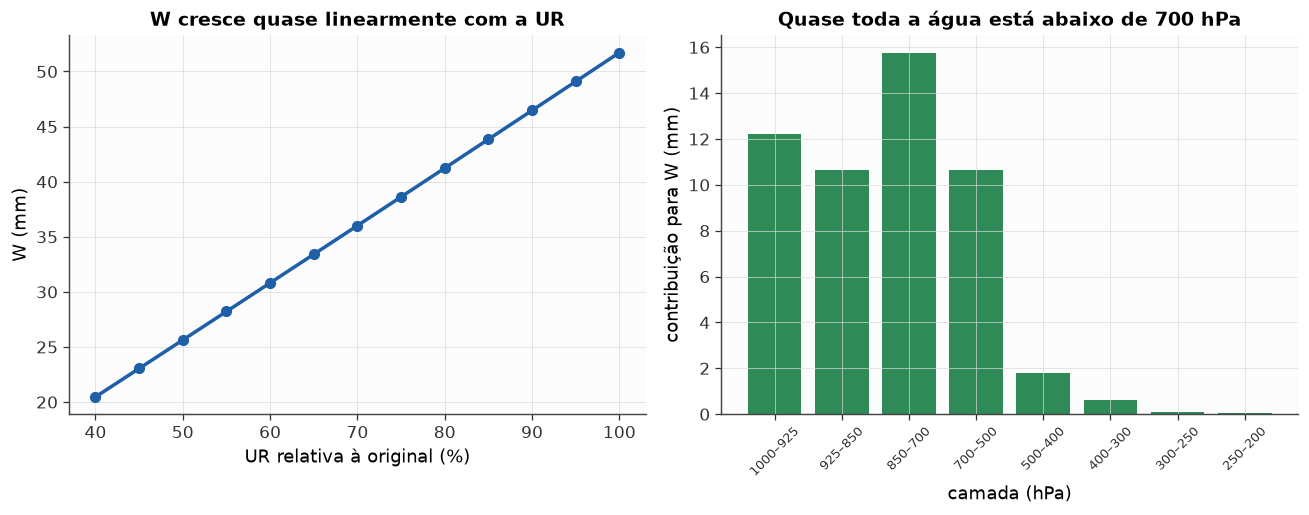

fração de W abaixo de 700 hPa: 75%


In [9]:
P_s  = np.array([1000, 925, 850, 700, 500, 400, 300, 250, 200]) * units.hPa
T_s  = np.array([27.0, 22.0, 17.5, 9.0, -6.5, -17.0, -32.0, -41.5, -53.0]) * units.degC
Td_s = np.array([22.0, 19.0, 15.0, 5.0, -14.0, -28.0, -45.0, -55.0, -68.0]) * units.degC
UR_s = mpcalc.relative_humidity_from_dewpoint(T_s, Td_s)

fats = np.linspace(0.4, 1.0, 13)
Ws = []
for f in fats:
    Td_mod = mpcalc.dewpoint_from_relative_humidity(T_s.to('K'), UR_s*f)
    Ws.append(mpcalc.precipitable_water(P_s, Td_mod).to('mm').magnitude)

# contribuição por camada (UR original)
r_orig = mpcalc.mixing_ratio_from_relative_humidity(P_s, T_s, UR_s)
dW = []
for i in range(len(P_s)-1):
    r_m = 0.5*(r_orig[i] + r_orig[i+1]).magnitude
    dP = (P_s[i] - P_s[i+1]).to('Pa').magnitude
    dW.append(r_m*dP/(1000.0*9.8)*1e3)   # mm

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 4.6))
ax1.plot(fats*100, Ws, 'o-', color=CORES['azul'])
ax1.set(xlabel='UR relativa à original (%)', ylabel='W (mm)',
        title='W cresce quase linearmente com a UR')
rot = [f'{P_s[i].magnitude:.0f}–{P_s[i+1].magnitude:.0f}' for i in range(len(dW))]
ax2.bar(rot, dW, color=CORES['verde'])
ax2.set(xlabel='camada (hPa)', ylabel='contribuição para W (mm)',
        title='Quase toda a água está abaixo de 700 hPa')
ax2.tick_params(axis='x', rotation=45, labelsize=8)
fig.tight_layout(); plt.show()
print(f'fração de W abaixo de 700 hPa: {100*sum(dW[:3])/sum(dW):.0f}%')

---
*Material derivado de R. Stull, Practical Meteorology (CC BY-NC-SA 4.0); este notebook herda a mesma licença.*